# Ridge Regression

## Objective

In this notebook, we will practice:

- Linear Regression baseline
- Feature Scaling
- Ridge Regression
- L2 Regularization
- Alpha parameter
- Coefficient shrinkage
- Model evaluation
- Comparing Linear Regression and Ridge Regression
- Comparing different alpha values


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [5]:
df = pd.read_csv(
    "../../heart_failure_clinical_records_dataset-selected-columns.csv"
)

df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex
0,75.0,0,582,0,20,1,265000.00,1.9,130,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0


In [6]:
print("Shape:", df.shape)

print(
    "Missing Values:",
    df.isnull().sum().sum()
)

df.describe()

Shape: (299, 10)
Missing Values: 0


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex
count,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.00000,299.000000,299.000000
mean,60.833893,0.431438,581.839465,0.418060,38.083612,0.351171,263358.029264,1.39388,136.625418,0.648829
std,11.894809,0.496107,970.287881,0.494067,11.834841,0.478136,97804.236869,1.03451,4.412477,0.478136
min,40.000000,0.000000,23.000000,0.000000,14.000000,0.000000,25100.000000,0.50000,113.000000,0.000000
25%,51.000000,0.000000,116.500000,0.000000,30.000000,0.000000,212500.000000,0.90000,134.000000,0.000000
50%,60.000000,0.000000,250.000000,0.000000,38.000000,0.000000,262000.000000,1.10000,137.000000,1.000000
75%,70.000000,1.000000,582.000000,1.000000,45.000000,1.000000,303500.000000,1.40000,140.000000,1.000000
max,95.000000,1.000000,7861.000000,1.000000,80.000000,1.000000,850000.000000,9.40000,148.000000,1.000000


# Preparing Data

For this practice:

### Features

- age
- creatinine_phosphokinase
- ejection_fraction
- platelets
- serum_sodium

### Target

- serum_creatinine

In [7]:
features = [
    "age",
    "creatinine_phosphokinase",
    "ejection_fraction",
    "platelets",
    "serum_sodium"
]

X = df[features]

y = df["serum_creatinine"]

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (299, 5)
y Shape: (299,)


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Rows:", len(X_train))
print("Testing Rows:", len(X_test))

Training Rows: 239
Testing Rows: 60


# Linear Regression Baseline

First, we create a normal Linear Regression model.

This gives us a baseline to compare with Ridge Regression.

In [9]:
linear_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

linear_pipeline.fit(
    X_train,
    y_train
)

linear_pred = linear_pipeline.predict(
    X_test
)

In [10]:
linear_mae = mean_absolute_error(
    y_test,
    linear_pred
)

linear_mse = mean_squared_error(
    y_test,
    linear_pred
)

linear_rmse = np.sqrt(
    linear_mse
)

linear_r2 = r2_score(
    y_test,
    linear_pred
)

print("Linear Regression")
print("MAE :", round(linear_mae, 3))
print("RMSE:", round(linear_rmse, 3))
print("R²  :", round(linear_r2, 3))

Linear Regression
MAE : 0.582
RMSE: 1.172
R²  : 0.01


# Ridge Regression

Ridge Regression adds L2 regularization to Linear Regression.

The `alpha` parameter controls the strength of regularization.

In [11]:
ridge_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0))
])

ridge_pipeline.fit(
    X_train,
    y_train
)

ridge_pred = ridge_pipeline.predict(
    X_test
)

In [12]:
ridge_mae = mean_absolute_error(
    y_test,
    ridge_pred
)

ridge_mse = mean_squared_error(
    y_test,
    ridge_pred
)

ridge_rmse = np.sqrt(
    ridge_mse
)

ridge_r2 = r2_score(
    y_test,
    ridge_pred
)

print("Ridge Regression")
print("MAE :", round(ridge_mae, 3))
print("RMSE:", round(ridge_rmse, 3))
print("R²  :", round(ridge_r2, 3))

Ridge Regression
MAE : 0.582
RMSE: 1.172
R²  : 0.01


In [13]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression"
    ],
    "MAE": [
        linear_mae,
        ridge_mae
    ],
    "RMSE": [
        linear_rmse,
        ridge_rmse
    ],
    "R²": [
        linear_r2,
        ridge_r2
    ]
})

comparison.round(3)

,Model,MAE,RMSE,R²
0,Linear Regression,0.582,1.172,0.01
1,Ridge Regression,0.582,1.172,0.01


In [14]:
ridge_model = ridge_pipeline.named_steps["model"]

ridge_coefficients = pd.DataFrame({
    "Feature": features,
    "Coefficient": ridge_model.coef_
})

ridge_coefficients

,Feature,Coefficient
0,age,0.104483
1,creatinine_phosphokinase,0.041100
2,ejection_fraction,0.048169
3,platelets,-0.062694
4,serum_sodium,-0.220737


In [15]:
linear_model = linear_pipeline.named_steps["model"]

coefficient_comparison = pd.DataFrame({
    "Feature": features,
    "Linear Regression": linear_model.coef_,
    "Ridge Regression": ridge_model.coef_
})

coefficient_comparison

,Feature,Linear Regression,Ridge Regression
0,age,0.104861,0.104483
1,creatinine_phosphokinase,0.041370,0.041100
2,ejection_fraction,0.048553,0.048169
3,platelets,-0.062941,-0.062694
4,serum_sodium,-0.221712,-0.220737


# Effect of Alpha

We will train Ridge models using different alpha values.

Small alpha:
- Weak regularization

Large alpha:
- Strong regularization

In [16]:
alphas = [
    0.01,
    0.1,
    1,
    10,
    100
]

results = []

for alpha in alphas:

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("ridge", Ridge(alpha=alpha))
    ])

    model.fit(
        X_train,
        y_train
    )

    predictions = model.predict(
        X_test
    )

    mae = mean_absolute_error(
        y_test,
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            predictions
        )
    )

    r2 = r2_score(
        y_test,
        predictions
    )

    results.append({
        "Alpha": alpha,
        "MAE": mae,
        "RMSE": rmse,
        "R²": r2
    })

alpha_results = pd.DataFrame(results)

alpha_results.round(3)

,Alpha,MAE,RMSE,R²
0,0.01,0.582,1.172,0.010
1,0.10,0.582,1.172,0.010
2,1.00,0.582,1.172,0.010
3,10.00,0.580,1.171,0.012
4,100.00,0.567,1.166,0.020


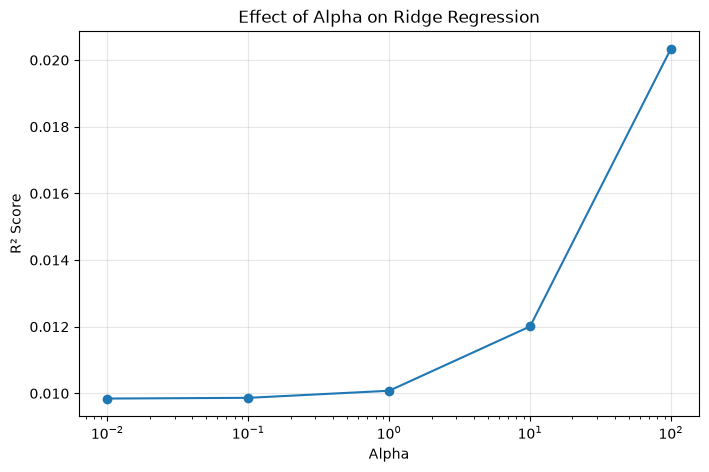

In [17]:
plt.figure(figsize=(8, 5))

plt.plot(
    alpha_results["Alpha"],
    alpha_results["R²"],
    marker="o"
)

plt.xscale("log")

plt.xlabel("Alpha")
plt.ylabel("R² Score")
plt.title("Effect of Alpha on Ridge Regression")

plt.grid(alpha=0.3)

plt.show()

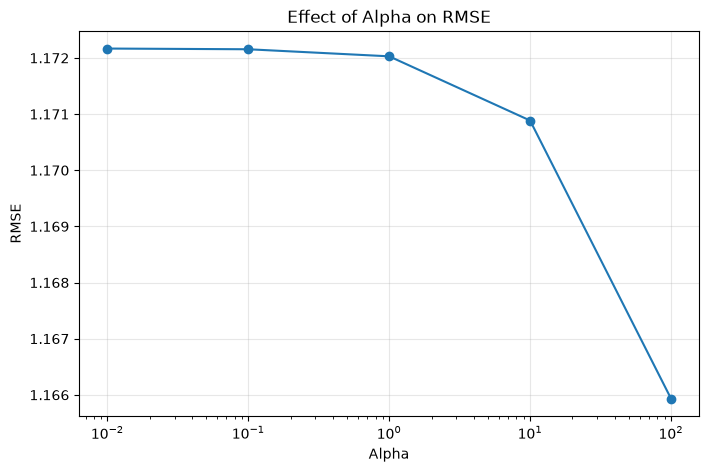

In [18]:
plt.figure(figsize=(8, 5))

plt.plot(
    alpha_results["Alpha"],
    alpha_results["RMSE"],
    marker="o"
)

plt.xscale("log")

plt.xlabel("Alpha")
plt.ylabel("RMSE")
plt.title("Effect of Alpha on RMSE")

plt.grid(alpha=0.3)

plt.show()

In [19]:
alpha_values = [
    0.01,
    1,
    100
]

coefficient_results = []

for alpha in alpha_values:

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("ridge", Ridge(alpha=alpha))
    ])

    model.fit(
        X_train,
        y_train
    )

    coefficients = (
        model.named_steps["ridge"].coef_
    )

    for feature, coefficient in zip(
        features,
        coefficients
    ):
        coefficient_results.append({
            "Alpha": alpha,
            "Feature": feature,
            "Coefficient": coefficient
        })

coefficient_results = pd.DataFrame(
    coefficient_results
)

coefficient_results.round(4)

,Alpha,Feature,Coefficient
0,0.01,age,0.1049
1,0.01,creatinine_phosphokinase,0.0414
2,0.01,ejection_fraction,0.0485
3,0.01,platelets,-0.0629
4,0.01,serum_sodium,-0.2217
5,1.00,age,0.1045
6,1.00,creatinine_phosphokinase,0.0411
7,1.00,ejection_fraction,0.0482
8,1.00,platelets,-0.0627
9,1.00,serum_sodium,-0.2207


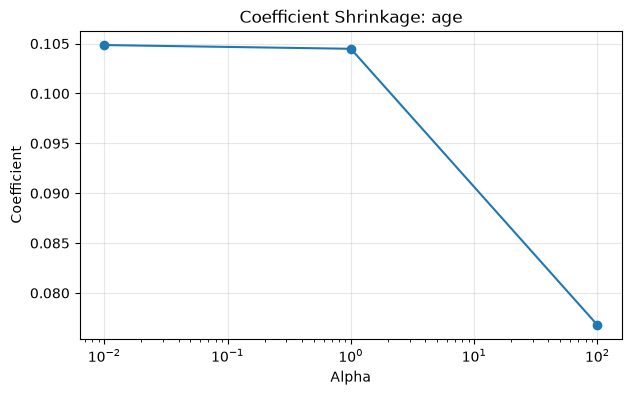

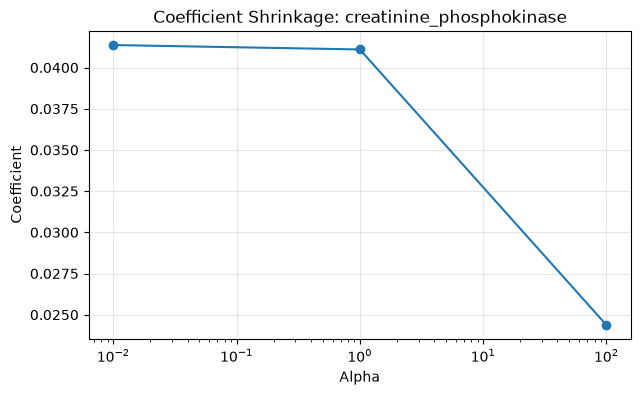

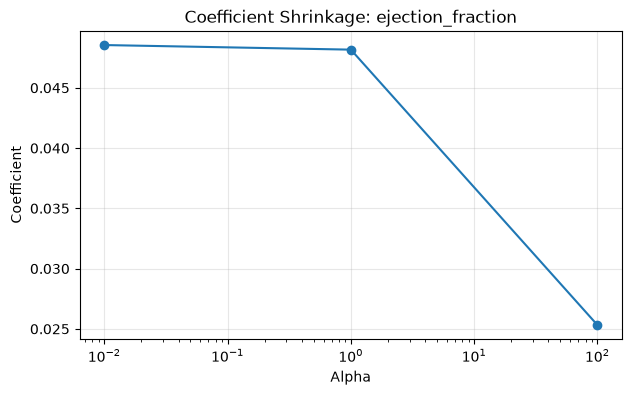

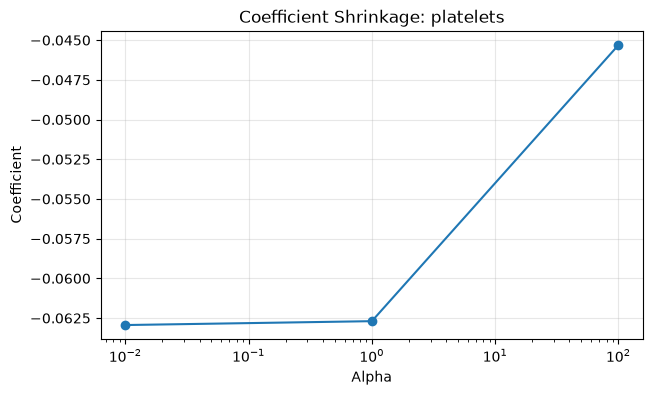

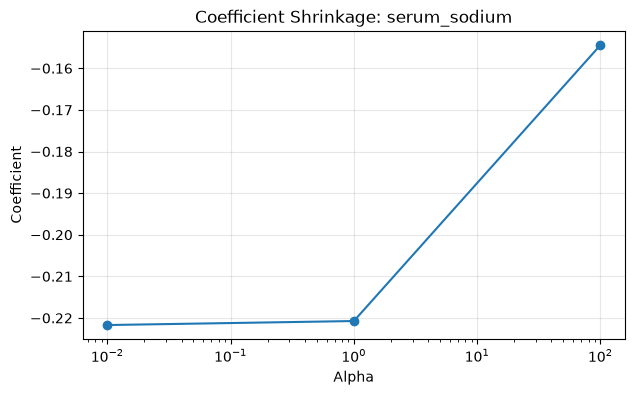

In [20]:
for feature in features:

    feature_data = coefficient_results[
        coefficient_results["Feature"] == feature
    ]

    plt.figure(figsize=(7, 4))

    plt.plot(
        feature_data["Alpha"],
        feature_data["Coefficient"],
        marker="o"
    )

    plt.xscale("log")

    plt.xlabel("Alpha")
    plt.ylabel("Coefficient")

    plt.title(
        f"Coefficient Shrinkage: {feature}"
    )

    plt.grid(alpha=0.3)

    plt.show()

# Summary

## Linear Regression

Linear Regression does not apply regularization.

## Ridge Regression

Ridge adds L2 regularization to control coefficient size.

## Alpha

- Small alpha → weak regularization
- Large alpha → strong regularization

## Coefficients

Ridge shrinks coefficients toward zero.

## Feature Scaling

Scaling is important because Ridge penalizes coefficient magnitudes.

## Model Comparison

We compared:

- Linear Regression
- Ridge Regression

using:

- MAE
- RMSE
- R²

## Important

Ridge is not automatically better than Linear Regression.

The appropriate regularization strength should be selected using validation or cross-validation.